<a href="https://colab.research.google.com/github/Valeriy1990/Else/blob/main/18_2_%D0%9E%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D0%BE%D0%B9_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9_%D1%81%D0%B5%D1%82%D0%B8_%D0%BD%D0%B0_%D0%BE%D0%B3%D1%80%D0%B0%D0%BD%D0%B8%D1%87%D0%B5%D0%BD%D0%BD%D0%BE%D0%BC_%D0%BD%D0%B0%D0%B1%D0%BE%D1%80%D0%B5_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

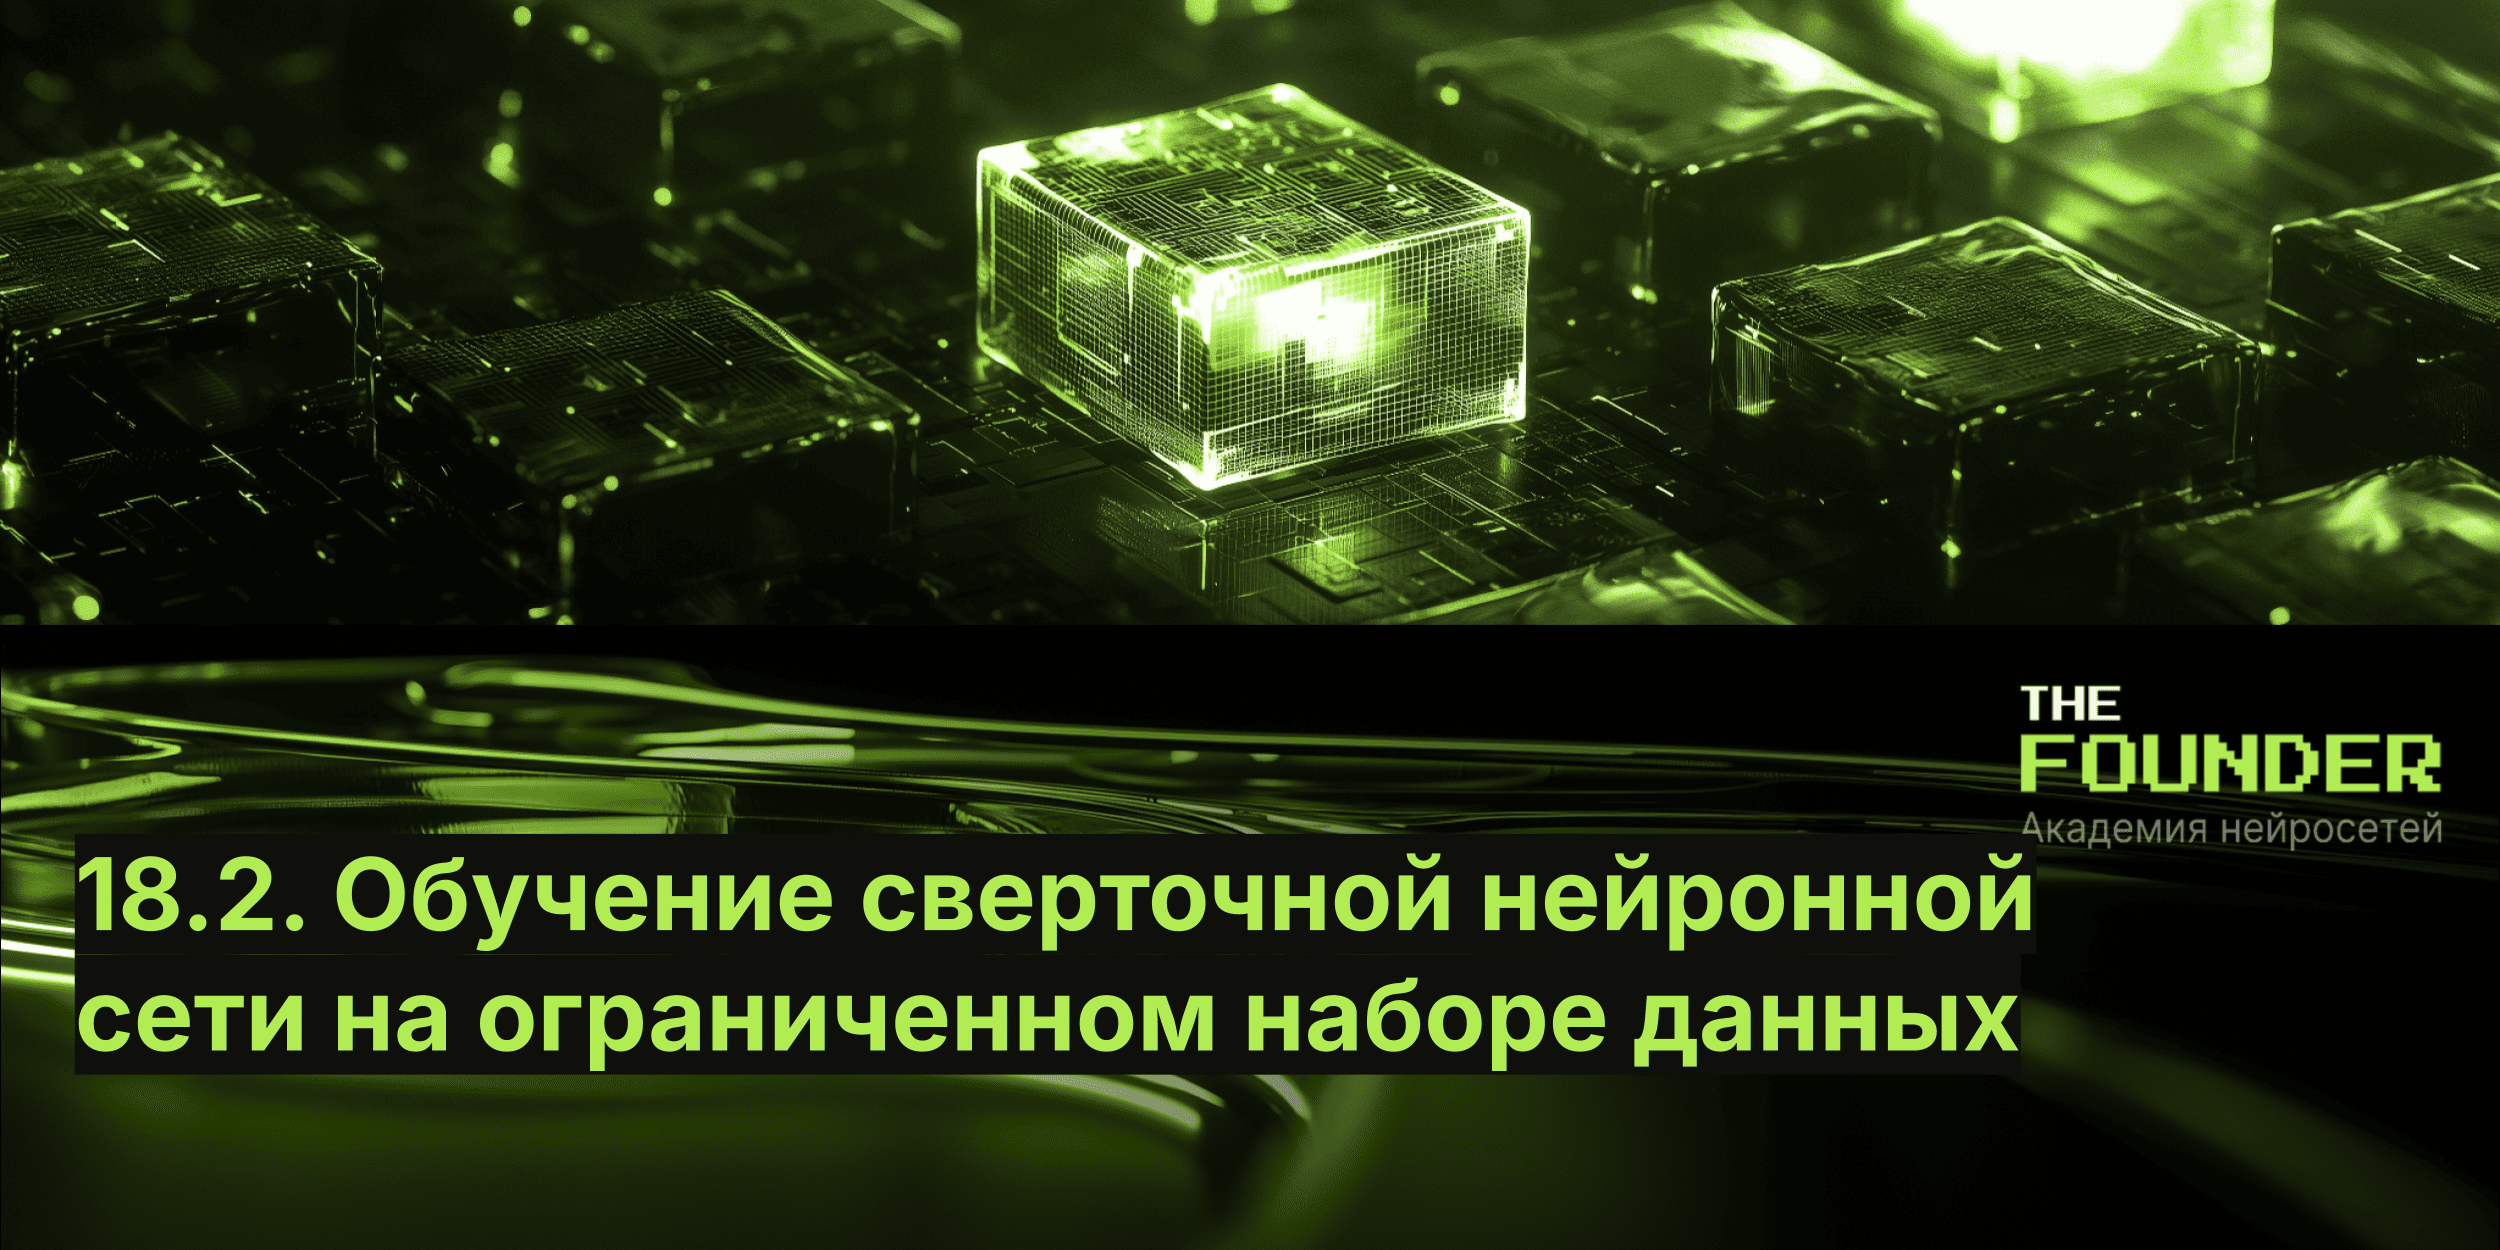

**Навигация по уроку**

1. [Введение в сверточные нейронные сети](https://colab.research.google.com/drive/10cBnEfHhZlv3ZhEgVimA3GqSEZtvqpTv)
2. Обучение сверточной нейронной сети на ограниченном наборе данных
3. [Предобученные сверточные НС](https://colab.research.google.com/drive/12VehrJe062P9QImtvjILQG0DOLooiyk0)
4. [Домашняя работа](https://colab.research.google.com/drive/18saeNkboTBS_5E9lxJ6xB4R0pawgxruY)

Необходимость обучения модели классификации изображений на ограниченном объеме данных — обычная ситуация, с которой вы наверняка столкнетесь в своей практике, если будете заниматься распознаванием образов с помощью технологий компьютерного зрения на профессиональном уровне. Под ограниченным
объемом мы понимаем датасет, состоящий из изображений численностью от нескольких сотен до нескольких десятков тысяч. В качестве практического примера рассмотрим классификацию изображений собак и кошек из набора данных, содержащего 4000 изображений (2000 кошек, 2000 собак).

Мы будем использовать 2000 изображений для обучения, 1000 для проверки и 1000 для контроля.

В данном уроке мы рассмотрим одну простую стратегию решения данной задачи.
Сначала мы обучим маленькую сверточную нейронную сеть на 2000 обучающих образцах без применения регуляризации, чтобы задать базовый уровень достижимого. Она даст нам точность классификации около 71 %.

С этого момента начнет проявляться эффект переобучения. Затем мы изучим эффективный способ уменьшения степени переобучения в распознавании образов — расширение данных (data augmentation). С его помощью мы повысим точность классификации до 82 %.

Далее мы рассмотрим еще два основных приема глубокого обучения на ограниченном наборе данных: выделение признаков с использованием предварительно обученной сети (поможет поднять точность с 90 до 96 %) и дообучение предварительно обученной сети (поможет достичь окончательной точности в 97 %).

Вместе эти три стратегии — обучение малой модели с нуля, выделение признаков с использованием предварительно обученной модели и дообучение этой модели — станут вашим основным набором инструментов для решения задач классификации
изображений с обучением на ограниченном наборе данных.

## Большой объем данных - это сколько?

Иногда можно услышать, что глубокое обучение можно применять только при
наличии большого (достаточного) объема данных. Это утверждение верно лишь отчасти: одна из основных характеристик глубокого обучения — возможность самостоятельно находить информативные признаки в обучающих данных, без конструирования признаков вручную, а это достижимо только при наличии большого объема обучающих примеров. Это особенно верно для задач, когда входные образцы имеют много измерений, как, например, изображения.

Однако понятие «большой объем данных» весьма относительное, в первую очередь
относительно размера и глубины обучаемой сети. Нельзя обучить сверточную
нейронную сеть решению сложной задачи на нескольких десятках образцов,
а вот нескольких сотен вполне может хватить, если модель невелика и регуляризована, а решаемая задача проста. Так как сверточные нейронные сети изучают локальные признаки, инвариантные в отношении переноса, они обладают высокой эффективностью в решении задач распознавания. Обучение сверточной
нейронной сети на небольшом наборе изображений дает вполне неплохие результаты, несмотря на относительную нехватку данных, без необходимости конструировать признаки вручную.

Более того, модели глубокого обучения по своей природе очень гибкие: можно,
к примеру, обучить модель для классификации изображений на очень большом наборе данных и затем использовать ее для решения самых разных задач с небольшими модификациями. Например, существует множество моделей в свободном доступе, предварительно обученных на наборах данных аналогичных ImageNet. Вы можете смело их использовать как основу для создания очень мощных моделей распознавания образов на небольших объемах данных. Такой эксперимент мы проведем в следующем колабе, а пока что сосредоточимся на обучении модели с нуля на "небольшом объеме данных".

## Задача о собаках и кошках

### Загрузка данных

Скачаем и извлечем датасет из архива:

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/cat-and-dog.zip

--2024-09-05 11:24:06--  https://storage.yandexcloud.net/academy.ai/cat-and-dog.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228082266 (218M) [application/x-zip-compressed]
Saving to: ‘cat-and-dog.zip’

cat-and-dog.zip     100%[===================>] 217.52M  6.01MB/s    in 41s     

2024-09-05 11:24:48 (5.31 MB/s) - ‘cat-and-dog.zip’ saved [228082266/228082266]



In [ ]:
# Разархивируем датасета во временную папку 'temp'
!unzip -qo "cat-and-dog" -d ./temp

# Папка с папками картинок, рассортированных по категориям
IMAGE_PATH = './temp/training_set/training_set/'

# Папка в которой будем создавать выборки
BASE_DIR = './dataset/'

Теперь можно посмотреть, что находится в загруженной папке. Для этого функцией `listdir()` из модуля **os** запросим список папок по адресу **IMAGE_PATH**:

In [ ]:
import os
os.listdir(IMAGE_PATH)

['cats', 'dogs']

Мы видим, что файлы распределены по папкам, при этом названия папок соответствуют именам классов (собаки и кошки). Поэтому зададим список классов из списка папок. Функция listdir() возвращает список папок в неопределенном порядке, поэтому список классов желательно отсортировать `sorted()`, чтобы имена классов всегда шли в одном порядке. Метками классов будут индексы имен классов в списке классов. Количество классов определим как длину списка классов.

In [ ]:
# Определение списка имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

# Проверка результата
print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

Количество классов: 2, метки классов: ['cats', 'dogs']


### Создание обучающей базы

Чтобы создать обучающую базу, нам понадобится список всех картинок животных, а также список номеров (меток) класса для них в том же порядке. То есть, например, для третьего по порядку файла в списке файлов метка его класса будет третьей в списке меток.

Сейчас изображения животных каждого класса лежат в отдельных папках. Загружая изображая, мы можем сразу записывать порядковый номер папки как метку класса животного в соответствующий список.

Количество классов равно **CLASS_COUNT**.

Пробежимся по содержимому папок, получим имена файлов изображений, соберем их в список **data_files**, а в список **data_labels** соберем номера (метки) классов:


In [ ]:
data_files = []  # Cписок путей к файлам изображений
data_labels = [] # Список меток классов

for class_label in range(CLASS_COUNT):    # Перебор по всем классам по порядку номеров (их меток)
    class_name = CLASS_LIST[class_label]  # Выборка имени класса из списка имен
    class_path = IMAGE_PATH + class_name  # Полный путь к папке с изображениями класса

    # Получение списка имен файлов с изображениями текущего класса
    class_files = os.listdir(class_path)

    # Вывод информации о численности класса
    print(f'Размер класса {class_name} составляет {len(class_files)} животных')

    # Добавление к общему списку всех файлов класса с добавлением родительского пути
    data_files += [f'{class_path}/{file_name}' for file_name in class_files]

    # Добавление к общему списку меток текущего класса - их ровно столько, сколько файлов в классе
    data_labels += [class_label] * len(class_files)

print('Общий размер базы для обучения:', len(data_labels))

Размер класса cats составляет 4000 животных
Размер класса dogs составляет 4005 животных
Общий размер базы для обучения: 8005


### Расщепление набора данных на обучающую, проверочную и контрольную выборки

Создадим папки для обучающей, проверочной и тестовой выборок:

In [ ]:
# Набор утилит для работы с файловой системой
import shutil

# При повторном запуске пересоздаим структуру каталогов
# Если папка существует, то удаляем ее со всеми вложенными каталогами и файлами
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

# Создаем папку по пути BASE_DIR
os.mkdir(BASE_DIR)

# Сцепляем путь до папки с именем вложенной папки. Аналогично BASE_DIR + 'train'
train_dir = os.path.join(BASE_DIR, 'train')

# Создаем подпапку, используя путь
os.mkdir(train_dir)

# Сцепляем путь до папки с именем вложенной папки. Аналогично BASE_DIR + 'validation'
validation_dir = os.path.join(BASE_DIR, 'validation')

# Создаем подпапку, используя путь
os.mkdir(validation_dir)

# Сцепляем путь до папки с именем вложенной папки. Аналогично BASE_DIR + 'test'
test_dir = os.path.join(BASE_DIR, 'test')

# Создаем подпапку, используя путь
os.mkdir(test_dir)

In [ ]:
# Функция создания подвыборок (папок с файлами)
def create_dataset(
    img_path: str,         # Путь к файлам с изображениями классов
    new_path: str,         # Путь к папке с выборками
    class_name: str,       # Имя класса (оно же и имя папки)
    start_index: int,      # Стартовый индекс изображения, с которого начинаем подвыборку
    end_index: int         # Конечный индекс изображения, до которого создаем подвыборку

):

    src_path = os.path.join(img_path, class_name)  # Полный путь к папке с изображениями класса
    dst_path = os.path.join(new_path, class_name)  # Полный путь к папке с новым датасетом класса

    # Получение списка имен файлов с изображениями текущего класса
    class_files = os.listdir(src_path)

    # Создаем подпапку, используя путь
    os.mkdir(dst_path)

    # Перебираем элементы, отобранного списка с начального по конечный индекс
    for fname in class_files[start_index : end_index]:
        # Путь к файлу (источник)
        src = os.path.join(src_path, fname)
        # Новый путь расположения файла (назначение)
        dst = os.path.join(dst_path, fname)
        # Копируем файл из источника в новое место (назначение)
        shutil.copyfile(src, dst)

In [ ]:
for class_label in range(CLASS_COUNT):    # Перебор по всем классам по порядку номеров (их меток)
    class_name = CLASS_LIST[class_label]  # Выборка имени класса из списка имен

    # Создаем обучающую выборку для заданного класса из диапазона (0-1000)
    create_dataset(IMAGE_PATH, train_dir, class_name, 0, 1000)
    # Создаем проверочную выборку для заданного класса из диапазона (1000-1500)
    create_dataset(IMAGE_PATH, validation_dir, class_name, 1000, 1500)
    # Создаем тестовую выборку для заданного класса из диапазона (1500-2000)
    create_dataset(IMAGE_PATH, test_dir, class_name, 1500, 2000)



С целью проверки подсчитаем, сколько изображений каждого класса оказалось в каждом наборе (обучающем/проверочном/контрольном):


In [ ]:
print('Число кошек %s, число собак %s в обучающей выборке' \
      % (
          len(os.listdir(os.path.join(train_dir, 'cats'))),
          len(os.listdir(os.path.join(train_dir, 'dogs')))
         )
      )

print('Число кошек %s, число собак %s в проверочной выборке' \
      % (
          len(os.listdir(os.path.join(validation_dir, 'cats'))),
          len(os.listdir(os.path.join(validation_dir, 'dogs')))
         )
      )

print('Число кошек %s, число собак %s в контрольной выборке' \
      % (
          len(os.listdir(os.path.join(test_dir, 'cats'))),
          len(os.listdir(os.path.join(test_dir, 'dogs')))
         )
      )


Число кошек 1000, число собак 1000 в обучающей выборке
Число кошек 500, число собак 500 в проверочной выборке
Число кошек 500, число собак 500 в контрольной выборке


Таким образом, мы видим, что у нас действительно имеется 2000 обучающих, 1000 проверочных и 1000 контрольных изображений. Каждый набор содержит одинаковое количество образцов каждого класса: это сбалансированная задача бинарной классификации,
соответственно, мерой успеха может служить точность классификации.

Сбалансированность означает, что в каждом классе у нас должно быть примерно одинаковое число кошек и собак. Разбалансировка классов приводит к резкому падению точности классификации.

Таким образом мы получили сбалансированные выборки. И можно приступить к созданию модели.

### Конструирование сети

Реализуем простую сверточную нейронную сеть, которая будет организована как стек чередующихся слоев `Conv2D` (с функцией активации `relu`) и `MaxPooling2D`.

По сравнению с задачей MNIST, в данном примере, мы имеем дело с большими изображениями и решаем более сложную задачу, а поэтому и сеть сделаем больше. Она будет иметь на одну пару слоев `Conv2D` + `MaxPooling2D` больше. Это увеличит ее емкость и обеспечит дополнительное снижение размеров карт признаков, чтобы они не оказались слишком большими, когда достигнут слоя `Flatten`.

С учетом того, что мы начнем с входов, имеющих размер $150 × 150$ (выбор был сделан совершенно произвольно), в конце, перед слоем `Flatten`, получится карта признаков размером $7 × 7$.

Глубина карт признаков в сети будет постепенно увеличиваться (с 32 до 128), а их размеры — уменьшаться (со $148 × 148$ до $7 × 7$). Этот шаблон вы будете видеть почти во всех сверточных нейронных сетях.

Так как перед нами стоит задача бинарной классификации, сеть должна заканчиваться единственным признаком (слой `Dense` с размером 1 и функцией активации `sigmoid`). Этот признак будет представлять собой вероятность принадлежности рассматриваемого изображения одному из двух классов.

In [ ]:
from keras import layers    # Импортируем слои
from keras import models    # Импортируем модели
model = models.Sequential() # Создаем модель как последовательность слоев

# Добавляем слои модели
model.add(layers.Conv2D(32, (3, 3), activation='relu',
 input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Посмотрим, как изменяются размеры карт признаков с каждым последующим слоем:

In [ ]:
# Выводим отчет модели по слоям
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,211,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

На этапе компиляции, как обычно, используем оптимизатор `RMSprop` или `Adam`. Так как сеть заканчивается единственным признаком, используем функцию потерь `binary_crossentropy`, в качестве метрики используем точность (`accuracy` или `acc`, что одно и тоже). Скорость обучения для `RMSprop` установим в `1e-4`, что в 10 раз меньше значения по умолчанию. Обучение будет медленнее, но более точно, так как при градиентном спуске вероятность проскочить через локальный минимум ниже.

In [ ]:
from keras import optimizers

# Оптимизатор можно задавать по имени с параметрами по умолчанию,
# а можно как метод с заданием значений параметров
# Описание параметров RMSprop - https://keras.io/api/optimizers/rmsprop/
model.compile(loss='binary_crossentropy',
 optimizer=optimizers.RMSprop(learning_rate=1e-4),
 metrics=['acc'])

### Предварительная обработка данных

Перед передачей в сеть данные необходимо преобразовать в тензоры с вещественными числами. В настоящее время данные хранятся в виде файлов JPEG, поэтому их нужно подготовить для передачи в сеть, выполнив следующие шаги, как любят говорить специалисты DataScience, необходимо выполнить следующий pipeline обработки данных:

1. Прочитать файлы с изображениями.
2. Декодировать содержимое из формата JPEG в таблицы пикселей RGB.
3. Преобразовать их в тензоры с вещественными числами.
4. Масштабировать значения пикселей из диапазона $[0, 255]$ в диапазон $[0, 1]$.

Этот порядок действий может показаться немного сложным, но, к счастью, в Keras имеются утилиты, способные выполнить его автоматически.

Во фреймворке Keras имеется модуль `keras.preprocessing.image` с инструментами для обработки изображений. В частности, в нем вы найдете класс `ImageDataGenerator`, который позволит быстро настроить генераторы Python для автоматического преобразования файлов с изображениями в пакеты готовых тензоров.

In [ ]:
BATCH_SIZE = 20

from tensorflow.keras.preprocessing.image import ImageDataGenerator # Импортируем генератор изображений

# Создаем генераторы для  обучающей и тестовой выборок
# Предварительно нормализуем данные делением на 255, приводим интесивность пикселей картинки к диапазону от 0 до 1
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Генерируем мини-батчи для обучения из заданной директории
train_generator = train_datagen.flow_from_directory(
    train_dir, # Целевой каталог
    target_size=(150, 150), # Привести все изображения к размеру 150 × 150
    batch_size=BATCH_SIZE, # Размер батча
    class_mode='binary'  # Делаем генерацию для задачи бинарной классификации (метки бинарные)
)

# Генерируем мини-батчи для проверки из заданной директории
validation_generator = test_datagen.flow_from_directory(
    validation_dir, # Целевой каталог
    target_size=(150, 150), # Привести все изображения к размеру 150 × 150
    batch_size=BATCH_SIZE, # Размер батча
    class_mode='binary'  # Делаем генерацию для задачи бинарной классификации (метки бинарные)
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Генератором в языке Python называется объект, действующий как итератор: его
можно использовать с инструкцией цикла `for ... in`. Работа генераторов основана
на использовании инструкции `yield`.

Чтобы было понятнее как работает генератор, приведем пример простого генератора, который выводит натуральные числа:

In [ ]:
def generator():
    i = 0
    while True:
        i += 1
        yield i


for item in generator():
    if item > 5:
        break
    print(item, end=' ')

1 2 3 4 5 

Рассмотрим вывод генератора обучения. Он возвращает пакеты изображений $150 × 150$ в формате RGB (с формой $(20, 150, 150, 3)$) и бинарные метки (с формой $(20,)$). В каждом пакете имеется 20 образцов (размер пакета).

Генератор возвращает пакеты до бесконечности. Он выполняет бесконечный цикл перебора изображений в целевом каталоге. По этой причине мы должны прервать цикл в некоторый момент:


In [ ]:
# Выводим с помощью генератора пакет с изображениями и метками
for data_batch, labels_batch in train_generator:
    print('Форма пакета с изображениями:', data_batch.shape)
    print('Форма пакета с метками:', labels_batch.shape)
    break

Форма пакета с изображениями: (20, 150, 150, 3)
Форма пакета с метками: (20,)


Напишем функцию для отображения содержимого батча:

In [ ]:
from PIL import Image                     # Отрисовка изображений
import random                             # Генерация случайных чисел
import matplotlib.pyplot as plt           # Построение графиков
import numpy as np                        # Работа с матрицами
%matplotlib inline


# Функция рисования образцов изображений из заданного батча генератора

def show_batch(batch,                # батч с примерами
               img_range=range(20),  # диапазон номеров картинок
               figsize=(25, 8),      # размер полотна для рисования одной строки таблицы
               columns=5             # число колонок в таблице
               ):

    for i in img_range: # Перебираем диапазон номеров картинок
        ix = i % columns # Отображаем по 5 (или другое число, заданное columns) в строку
        # Остаток от деления на 5 равный нулю говорит, что пора перейти на следующую строку (новый график)
        if ix == 0:
            fig, ax = plt.subplots(1, columns, figsize=figsize) # Область построения графика: одна строка в 5 колонок
        class_label = int(batch[1][i]) # Извлекаем номер класса
        ax[ix].set_title(CLASS_LIST[class_label]) # Отображаем заголовок конкретного рисунка
        ax[ix].imshow(batch[0][i]) # Отображаем изображение животного на графике
        ax[ix].axis('off') # Отключаем отображение осей на графике
        plt.tight_layout() # Автоматически настраивает параметры подзаголовка так, чтобы подзаголовок вписывался в область рисунка

    plt.show() # Отображаем все графики со всеми рисунками

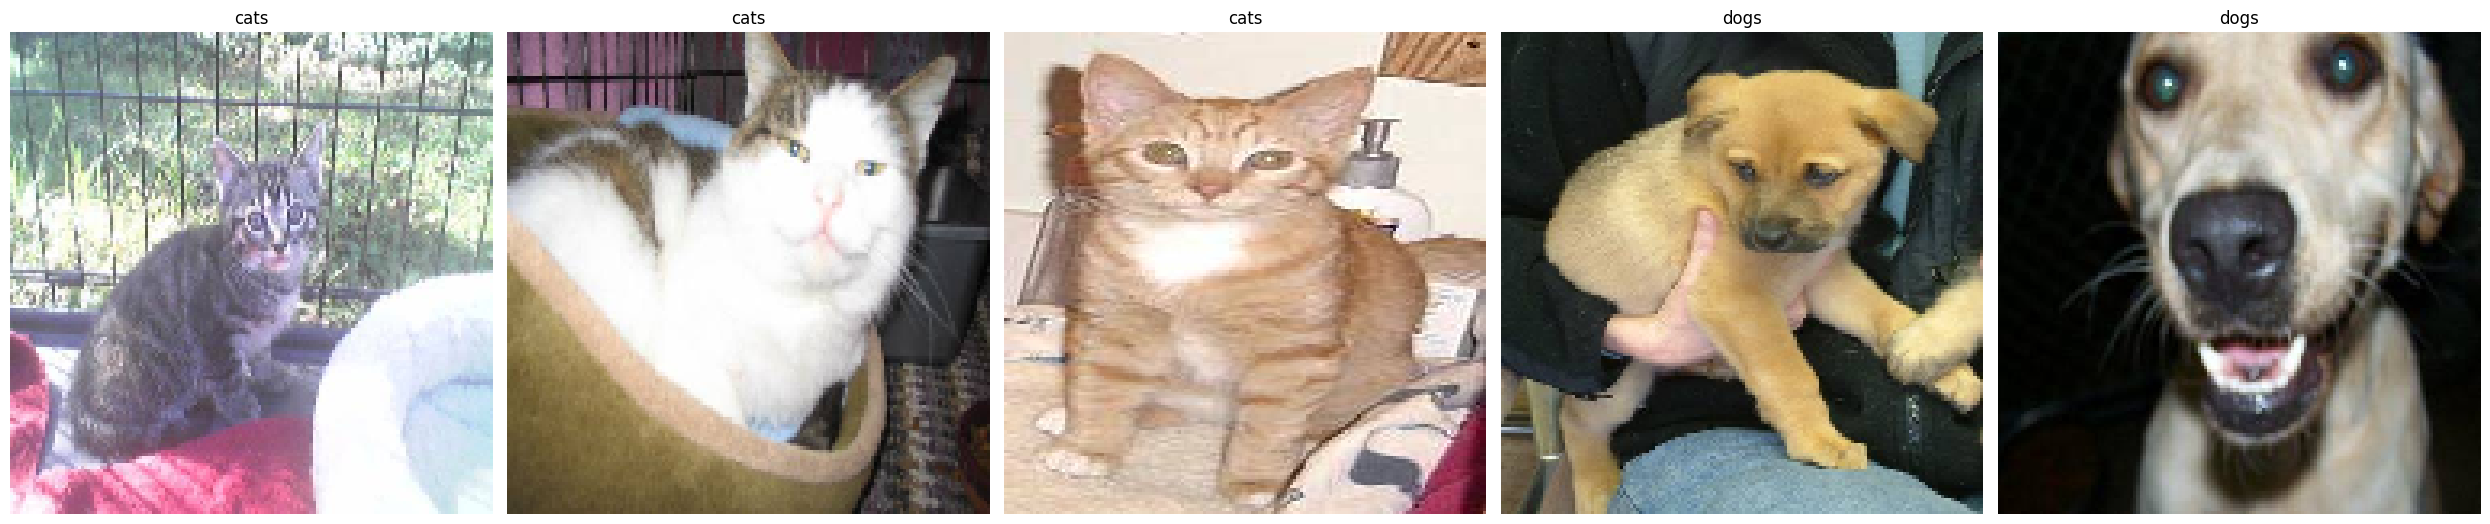

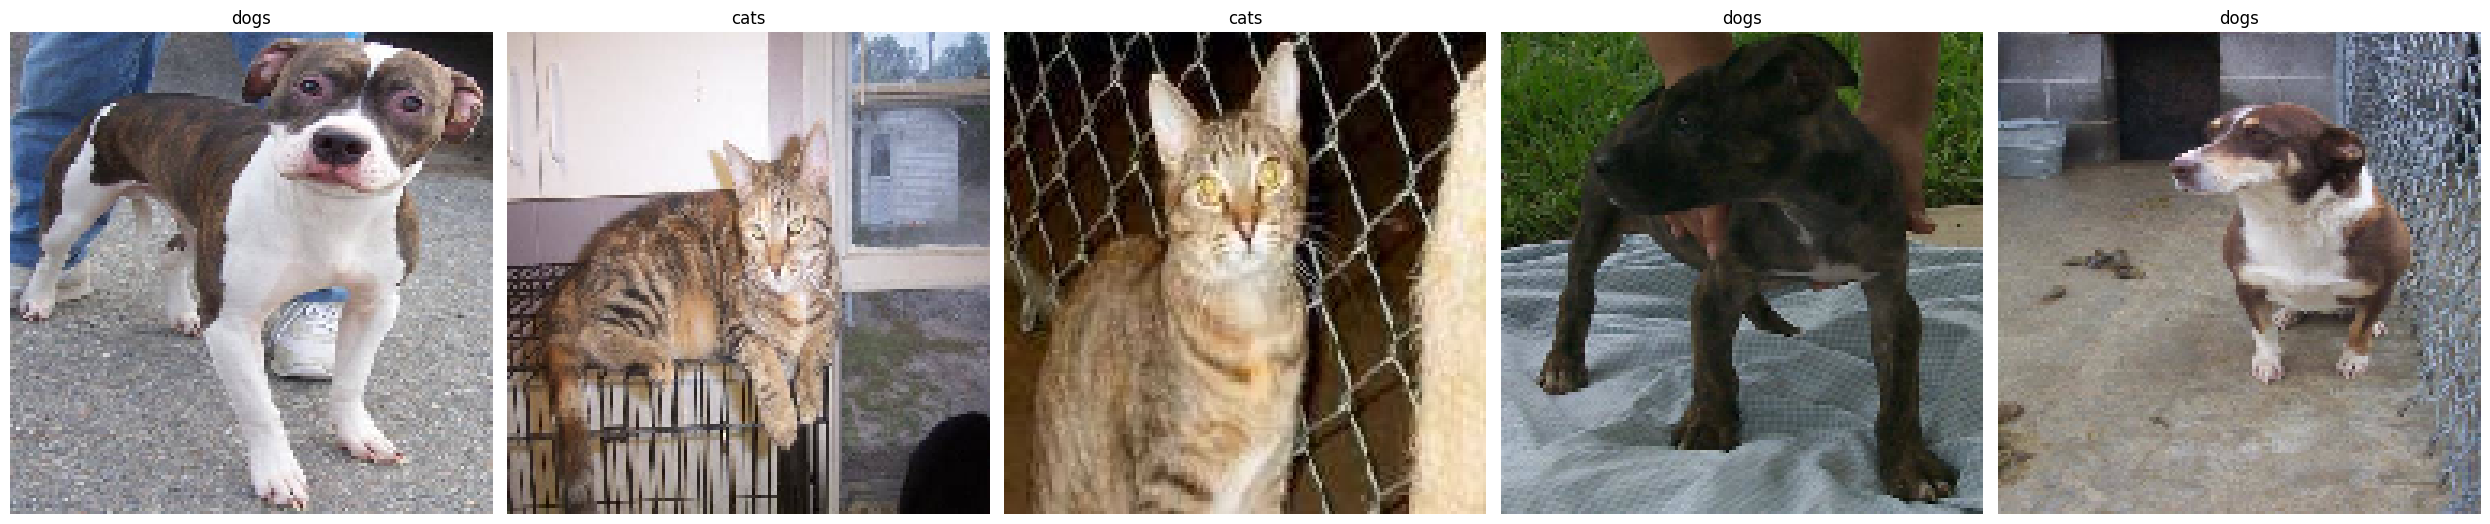

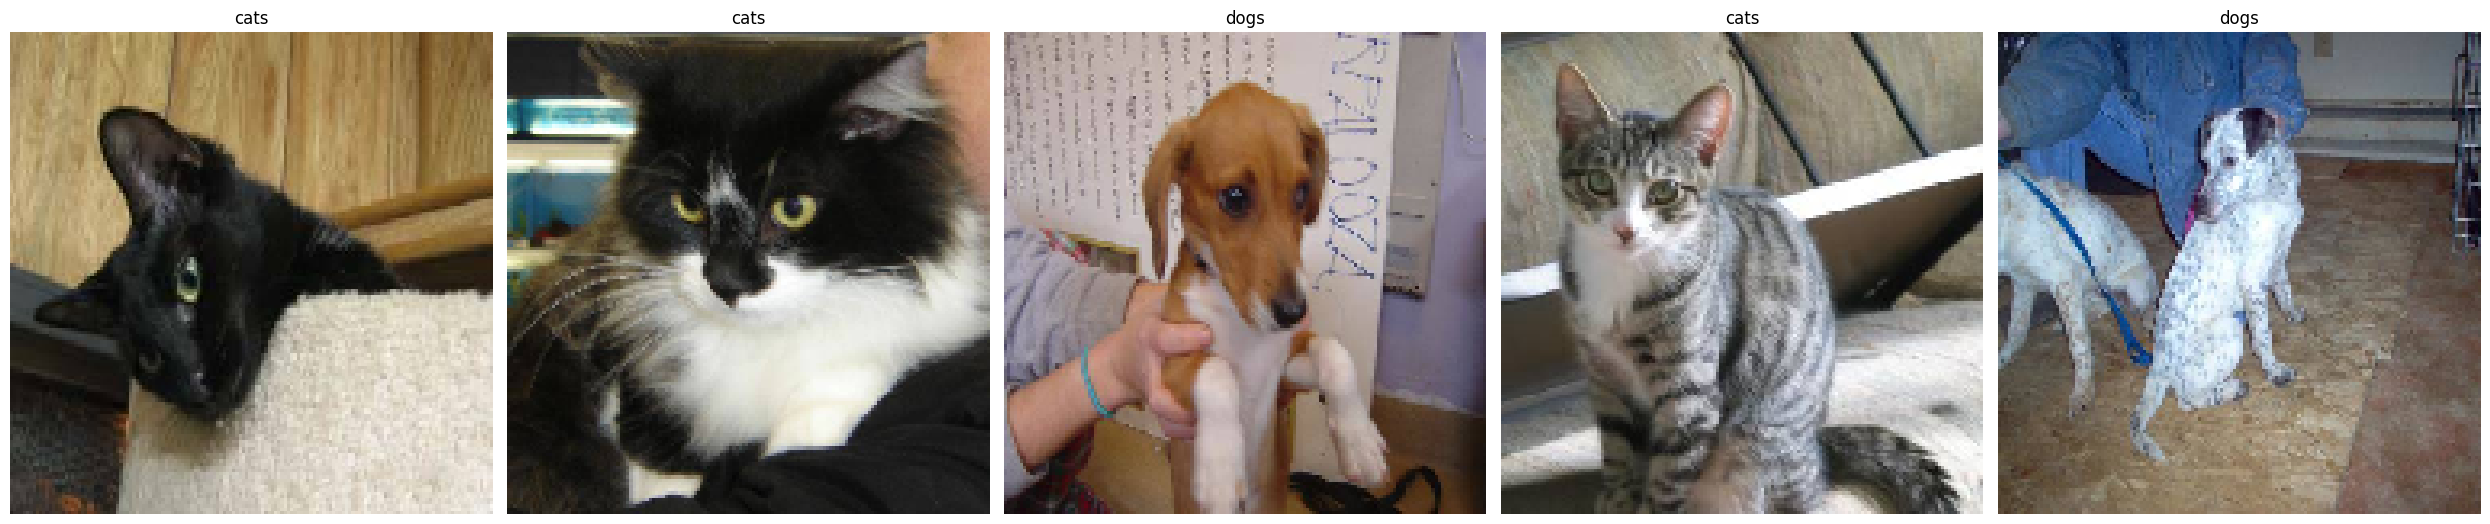

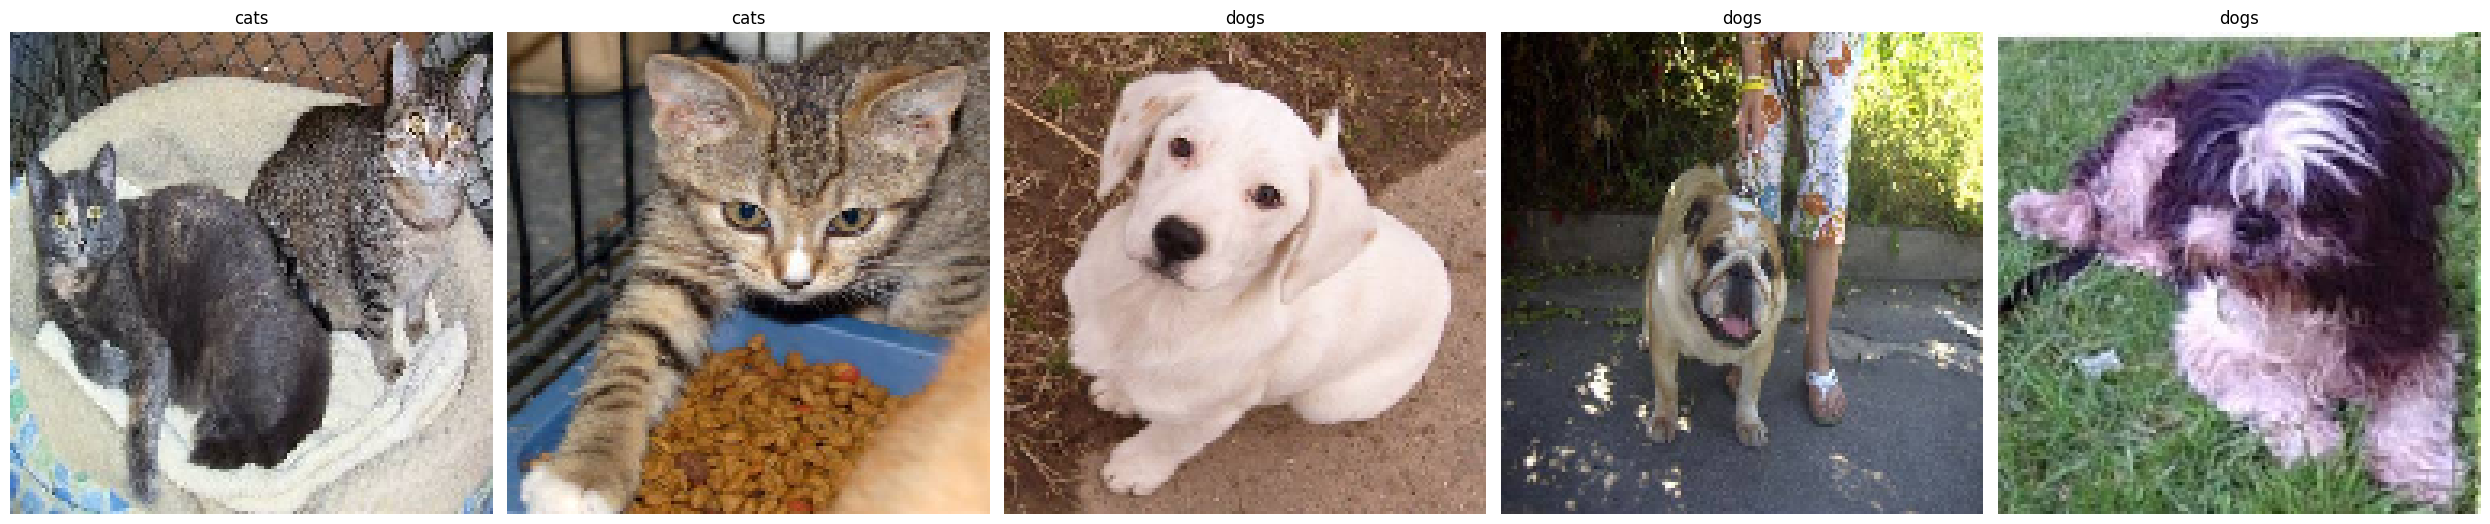

In [ ]:
show_batch(validation_generator[0]) # рисуем батч

Передадим исходные данные в модель с помощью генератора. Используем для этого знакомый нам метод `fit`, который умеет работать с генераторами данных. В первом аргументе мы передаем методу генератор `train_generator`, который возвращает пакеты входных данных и меток.

Что касается аргумента `validation_data`, то важно отметить, что этот аргумент может быть не только генератором данных, но также кортежем массивов Numpy. Если
в validation_data передать генератор, предполагается, что он будет возвращать
пакеты проверочных данных.

In [ ]:
# цикл обучения
history = model.fit(
    train_generator,                        # генератор для обучения
    epochs=30,                              # число эпох обучения
    validation_data=validation_generator,   # генератор проверочной выборки
)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - acc: 0.4908 - loss: 0.6960 - val_acc: 0.5850 - val_loss: 0.6825
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - acc: 0.5966 - loss: 0.6745 - val_acc: 0.6110 - val_loss: 0.6691
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - acc: 0.6326 - loss: 0.6546 - val_acc: 0.5630 - val_loss: 0.6704
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - acc: 0.6338 - loss: 0.6291 - val_acc: 0.6420 - val_loss: 0.6270
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - acc: 0.6649 - loss: 0.6113 - val_acc: 0.6340 - val_loss: 0.6142
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - acc: 0.7091 - loss: 0.5621 - val_acc: 0.6720 - val_loss: 0.5961
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - acc: 0.7194 - loss: 0.5465 - val_acc: 0.6610 - val_loss: 0.6094
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - acc: 0.7377 - loss: 0.5271 - val_acc: 0.6790 - val_loss: 0.5987
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - 

Хорошей практикой считается всегда сохранять модели после обучения:

In [ ]:
model.save('cats_and_dogs_small_model.h5') # сохраняем модель

Построим графики динамики точности и потерь модели по обучающим и проверочным данным в процессе обучения:

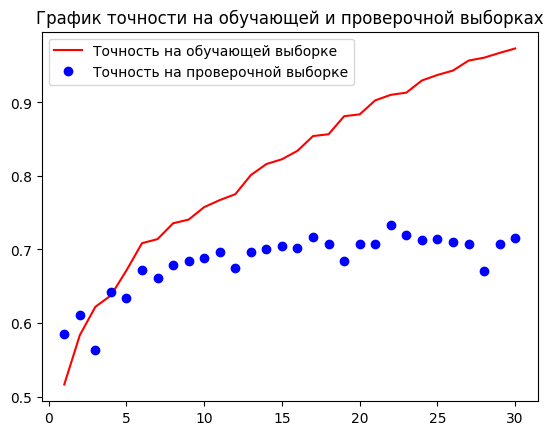

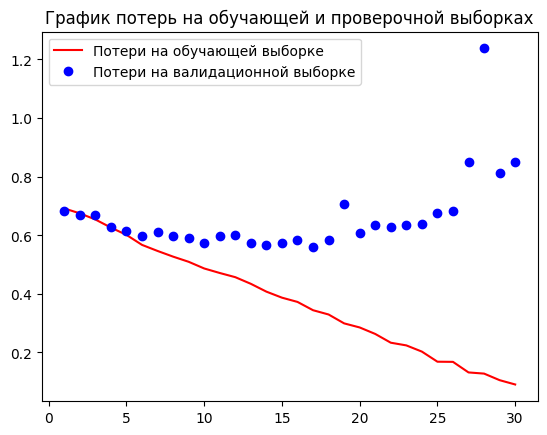

In [ ]:
import matplotlib.pyplot as plt           # библиотека для рисования графиков
acc = history.history['acc']              # данные о точности на обучающей выборке
val_acc = history.history['val_acc']      # данные о точности на проверочной выборке
loss = history.history['loss']            # данные об ошибке на обучающей выборке
val_loss = history.history['val_loss']    # данные об ошибке на проверочной выборке
epochs = range(1, len(acc) + 1)           # массив со значениями для оси абсцисс (Х)
plt.plot(epochs, acc, 'r', label='Точность на обучающей выборке')          #  строим график точность на обучающей выборке
plt.plot(epochs, val_acc, 'bo', label='Точность на проверочной выборке')   #  строим график точность на проверочной выборке
plt.title('График точности на обучающей и проверочной выборках')           #  заголовок графика
plt.legend()                                                               #  легенда графика
plt.figure()                                                               #  создаем новую фигуру (полотно для графика)
plt.plot(epochs, loss, 'r', label='Потери на обучающей выборке')           #  строим график потерь (ошибки) на обучающей выборке
plt.plot(epochs, val_loss, 'bo', label='Потери на валидационной выборке')  #  строим график потерь на проверочной выборке
plt.title('График потерь на обучающей и проверочной выборках')             #  заголовок графика
plt.legend()                                                               #  легенда графика
plt.show()                                                                 #  рисуем график

На графиках четко наблюдается эффект переобучения. Точность на обучающих
данных линейно растет и приближается к 100 %, тогда как точность на проверочных
данных останавливается на отметке 70–71 %. Потери на этапе проверки достигают
минимума всего после пяти эпох и затем замирают, а потери на этапе обучения
продолжают линейно уменьшаться, почти достигая 0.
Поскольку у нас относительно немного обучающих образцов (2000), переобучение становится проблемой номер один. Но мы уже познакомились с несколькими методами, помогающих смягчить эту проблему, таких как прореживание и сокращение весов (L2-регуляризация).

Теперь мы познакомимся с еще одним способом, характерным для распознавания образов и используемым почти повсеместно при обработке изображений с применением моделей глубокого обучения: способом расширения данных (data augmentation).

### Аугментация (расширение данных)

Причиной переобучения является недостаточное количество образцов для обучения модели, способной обобщать новые данные. Имея бесконечный объем данных, можно было бы получить модель, учитывающую все аспекты распределения данных: эффект переобучения никогда не наступил бы.

Прием расширения данных реализует подход создания дополнительных обучающих данных из имеющихся, путем трансформации образцов множеством случайных преобразований, дающих правдоподобные изображения.

Цель состоит в том, чтобы на этапе обучения модель никогда не увидела одно и то же изображение дважды.

Это поможет модели выявить больше особенностей данных и достичь лучшей
степени обобщения.

Сделать это в Keras можно путем настройки ряда случайных преобразований для
изображений, читаемых экземпляром ImageDataGenerator. Начнем с простого
примера.

In [ ]:
datagen = ImageDataGenerator(
 rotation_range=40,
 width_shift_range=0.2,
 height_shift_range=0.2,
 shear_range=0.2,
 zoom_range=0.2,
 horizontal_flip=True,
 fill_mode='nearest')

Здесь представлена лишь часть возможных вариантов (полный список вы
найдете в документации к фреймворку Keras).

В примере выше используются следующие преобразования:
* `rotation_range` — величина в градусах $(0–180)$, диапазон, в котором будет осуществляться случайный поворот изображения;
* `width_shift` и `height_shift` — диапазоны (в долях ширины и высоты), в пределах которых изображения смещаются по горизонтали и вертикали соответственно;
* `shear_range` — cлучайный сдвиг;
* `zoom_range` — случайное изменения масштаба;
* `horizontal_flip` — случайное отражение изображения по горизонтали;
* `fill_mode` — стратегия заполнения пустых пикселов, появляющихся после поворота или смещения по горизонтали/вертикали.

Выведем случайное изображение и проведем над ним аугментацию:

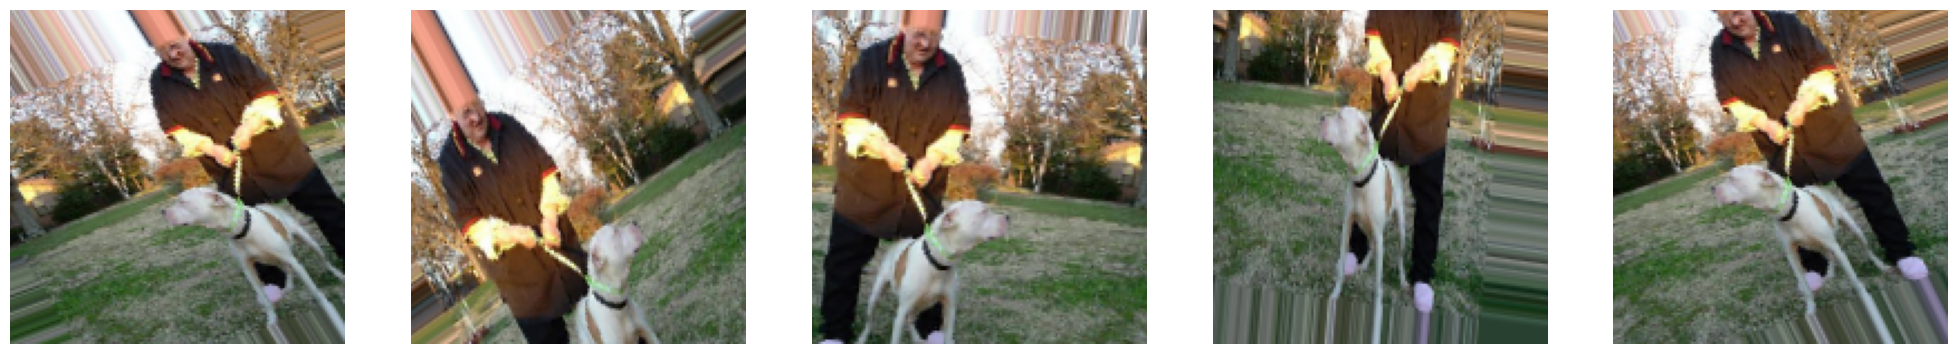

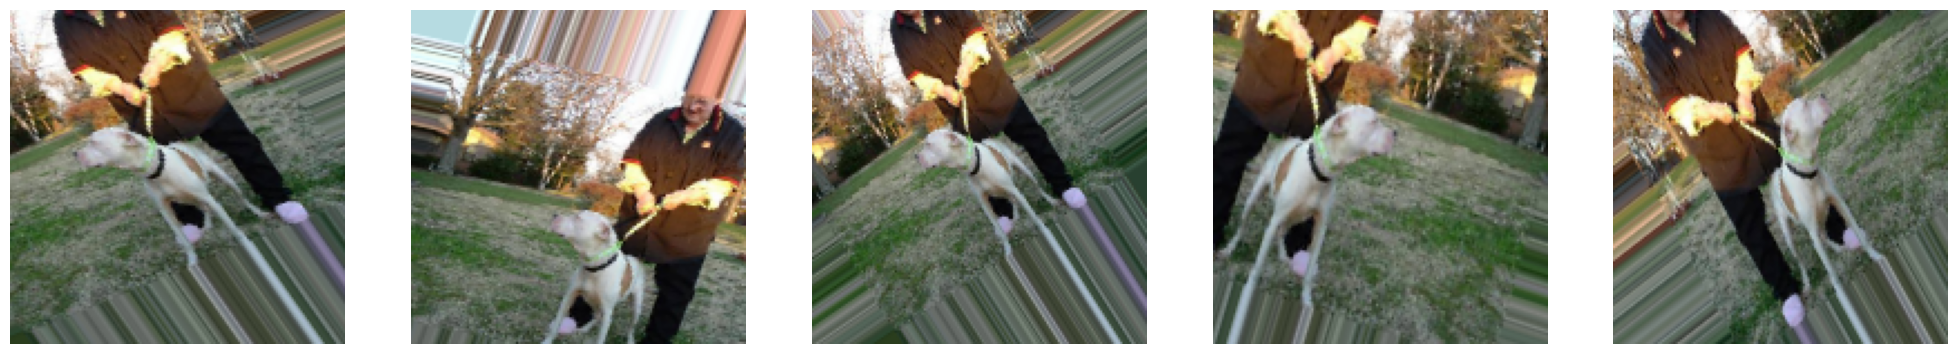

In [ ]:
from keras.preprocessing import image # для работы с изображениями

img = validation_generator[0][0][7]   # выводим случайную картинку с помощью генератора (первый индекс - картинка или метка, второй - номер пакета, третий - номер изображения в пакете)
x = image.img_to_array(img)           # преобразования изображений в матрицу NumPy
x = x.reshape((1,) + x.shape)         # изменяем форму картинки, так как flow работет с массивами изображений, то указываем, что картинка будет одна
columns = 5                           # в сколько колонок выводить данные

i = 0
for batch in datagen.flow(x, batch_size=1):  # запускаем генерацию их массива изображений, пока не встретиться в цикле break
    ix = i % columns # Отображаем по 5 (или другое число, заданное columns) в строку
    # Остаток от деления на 5 равный нулю говорит, что пора перейти на следующую строку (новый график)
    if ix == 0:
        fig, ax = plt.subplots(1, columns, figsize=(25, 8)) # Область построения графика: одна строка в 5 колонок

    ax[ix].imshow(image.array_to_img(batch[0])) # Отображаем изображение животного на графике
    ax[ix].axis('off') # Отключаем отображение осей на графике

    i += 1
    if i % 10 == 0: # если сгенерировали 10 картинок, то можно прервать генерацию
        break
plt.show()

Если обучить новую сеть с использованием этих настроек аугментации (расширения данных), она никогда не увидит одно и то же изображение дважды. Однако входные данные попрежнему будут тесно связаны между собой, потому что получены из небольшого количества оригинальных изображений. Сгенерировать новую информацию все же не получиться, мы лишь можем только повторить существующую. Поэтому данного решения недостаточно, чтобы избавиться от эффекта переобучения. Продолжая борьбу с ним, добавим в модель слой `Dropout` непосредственно перед полносвязным классификатором.

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Обучим сеть c учетом аугментации и прореживания:

In [ ]:
BATCH_SIZE = 24

# генератор для обучающей выборки
train_datagen = ImageDataGenerator(
    rescale=1./255,           # нормализация данных
    rotation_range=40,        # поворот 40 градусов
    width_shift_range=0.2,    # смещенние изображения по горизонтали
    height_shift_range=0.2,   # смещенние изображения по вертикали
    shear_range=0.2,          # случайный сдвиг
    zoom_range=0.2,           # случайное масштабирование
    horizontal_flip=True,     # отражение по горизонтали
)

# генератор для проверочной выборки
test_datagen = ImageDataGenerator(rescale=1./255)

# генерация картинок из папки для обучающей выборки
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# генерация картинок из папки для проверочной выборки
validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)



Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:
# обучаем модель
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator # число шагов вычисляем как число образцов на размер пакета
)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 222ms/step - acc: 0.4883 - loss: 0.6989 - val_acc: 0.5000 - val_loss: 0.7074
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 169ms/step - acc: 0.5341 - loss: 0.6874 - val_acc: 0.5290 - val_loss: 0.6839
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 169ms/step - acc: 0.5582 - loss: 0.6789 - val_acc: 0.5580 - val_loss: 0.6798
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 179ms/step - acc: 0.5718 - loss: 0.6729 - val_acc: 0.5660 - val_loss: 0.6825
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - acc: 0.5544 - loss: 0.6792 - val_acc: 0.5740 - val_loss: 0.6739
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - acc: 0.6060 - loss: 0.6614 - val_acc: 0.5190 - val_loss: 0.7349
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - acc: 0.5705 - loss: 0.6709 - val_acc: 0.5650 - val_loss: 0.6843
Epoch 8/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - acc: 0.6183 - loss: 0.6489 - val_acc: 0.5880 - val_loss: 0.6643
Epoch 9/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 183ms/ste

Теперь можно сохранить улучшенную модель:

In [ ]:
model.save('cats_and_dogs_small_2.h5')

Взглянем на графики:

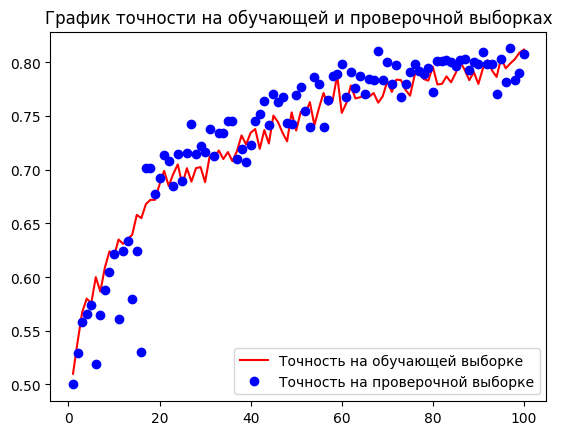

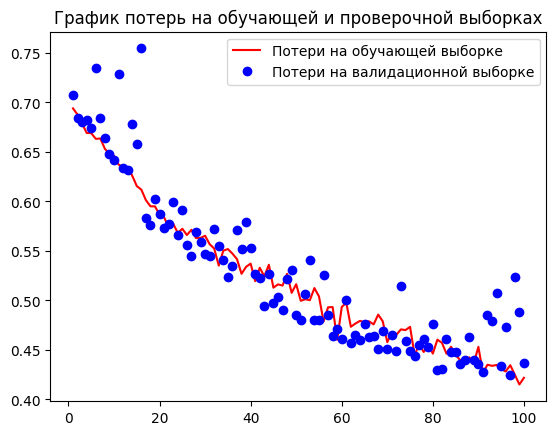

In [ ]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'r', label='Точность на обучающей выборке')
plt.plot(epochs, val_acc, 'bo', label='Точность на проверочной выборке')
plt.title('График точности на обучающей и проверочной выборках')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'r', label='Потери на обучающей выборке')
plt.plot(epochs, val_loss, 'bo', label='Потери на валидационной выборке')
plt.title('График потерь на обучающей и проверочной выборках')
plt.legend()
plt.show()

Применив расширение
данных и прореживание, мы практически избавились от переобучения: кривые
точности и потерь на этапе обучения близки к аналогичным кривым на этапе проверки. Теперь мы достигли точности 81 %, улучшив ее в сравнении с нерегуляризованной моделью. Несмотря на сильное колебание точности, от эпохи к эпохи, мы всегда можем сохранить лучшую модель и ее использовать (но об этом немного позже, наберитесь терпения).

Использовав дополнительные методы регуляризации и настроив параметры сети
(например, число фильтров на сверточный слой или число слоев в сети), можно добиться еще более высокой точности, примерно 85 %. Однако будет очень
трудно подняться выше этой отметки, обучая сверточную нейронную сеть с нуля,
потому что у нас слишком мало данных.

Следующий шаг к увеличению точности решения этой задачи заключается в использовании [предварительно обученной модели](https://colab.research.google.com/drive/12VehrJe062P9QImtvjILQG0DOLooiyk0).